# Submission Analysis: 유저-아이템 시간 불일치 분석

## 목적
예측해야 할 10개 아이템 중, 유저의 활동 기간과 맞지 않는 아이템이 얼마나 있는가?

## 판단 기준
```
유저의 마지막 활동 시점 + margin < 아이템의 첫 상호작용 시점
→ 불일치 (시간적으로 불가능한 예측)
```

## 한계
- 아이템의 첫 상호작용은 train 데이터 기준 (원본에서 10개 제거된 상태)
- 실제 첫 상호작용은 더 이를 수 있음

---
## 0. 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import os
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../../data/train/'
SUBMISSION_PATH = './'

print("Setup complete.")

Setup complete.


In [2]:
# Train 데이터 로드
ratings = pd.read_csv(os.path.join(DATA_PATH, 'train_ratings.csv'))
ratings['datetime'] = pd.to_datetime(ratings['time'], unit='s')

print(f"Train 데이터: {len(ratings):,}개 상호작용")
print(f"유저 수: {ratings['user'].nunique():,}")
print(f"아이템 수: {ratings['item'].nunique():,}")

Train 데이터: 5,154,471개 상호작용
유저 수: 31,360
아이템 수: 6,807


In [3]:
# 제출 파일 로드
submission = pd.read_csv(os.path.join(SUBMISSION_PATH, 'output.csv'))

print(f"\n제출 파일: {len(submission):,}개 예측")
print(f"유저 수: {submission['user'].nunique():,}")
print(f"유저당 예측 수: {len(submission) // submission['user'].nunique()}")
print(f"\n처음 5행:")
print(submission.head())


제출 파일: 313,600개 예측
유저 수: 31,360
유저당 예측 수: 10

처음 5행:
   user   item
0    11  58025
1    11   4370
2    11  37386
3    11      2
4    11  55232


In [4]:
# 유저별 마지막 활동 시점 계산
user_last_activity = ratings.groupby('user')['datetime'].max().to_dict()
user_last_time = ratings.groupby('user')['time'].max().to_dict()

# 아이템별 첫 상호작용 시점 계산 (train 기준)
item_first_interaction = ratings.groupby('item')['datetime'].min().to_dict()
item_first_time = ratings.groupby('item')['time'].min().to_dict()

print("유저별 마지막 활동 시점, 아이템별 첫 상호작용 시점 계산 완료")

유저별 마지막 활동 시점, 아이템별 첫 상호작용 시점 계산 완료


---
## 1. 기본 통계

In [5]:
# 유저별 마지막 활동 시점 분포
user_last_dates = pd.Series(user_last_activity)

print("[유저별 마지막 활동 시점]")
print(f"최소: {user_last_dates.min()}")
print(f"최대: {user_last_dates.max()}")
print(f"중앙값: {user_last_dates.median()}")

[유저별 마지막 활동 시점]
최소: 2005-04-11 13:54:15
최대: 2015-03-31 05:50:52
중앙값: 2010-05-14 17:34:38.500000


In [6]:
# 아이템별 첫 상호작용 시점 분포
item_first_dates = pd.Series(item_first_interaction)

print("[아이템별 첫 상호작용 시점 (train 기준)]")
print(f"최소: {item_first_dates.min()}")
print(f"최대: {item_first_dates.max()}")
print(f"중앙값: {item_first_dates.median()}")

[아이템별 첫 상호작용 시점 (train 기준)]
최소: 2005-04-11 11:56:25
최대: 2015-01-03 05:32:06
중앙값: 2005-04-21 12:33:21


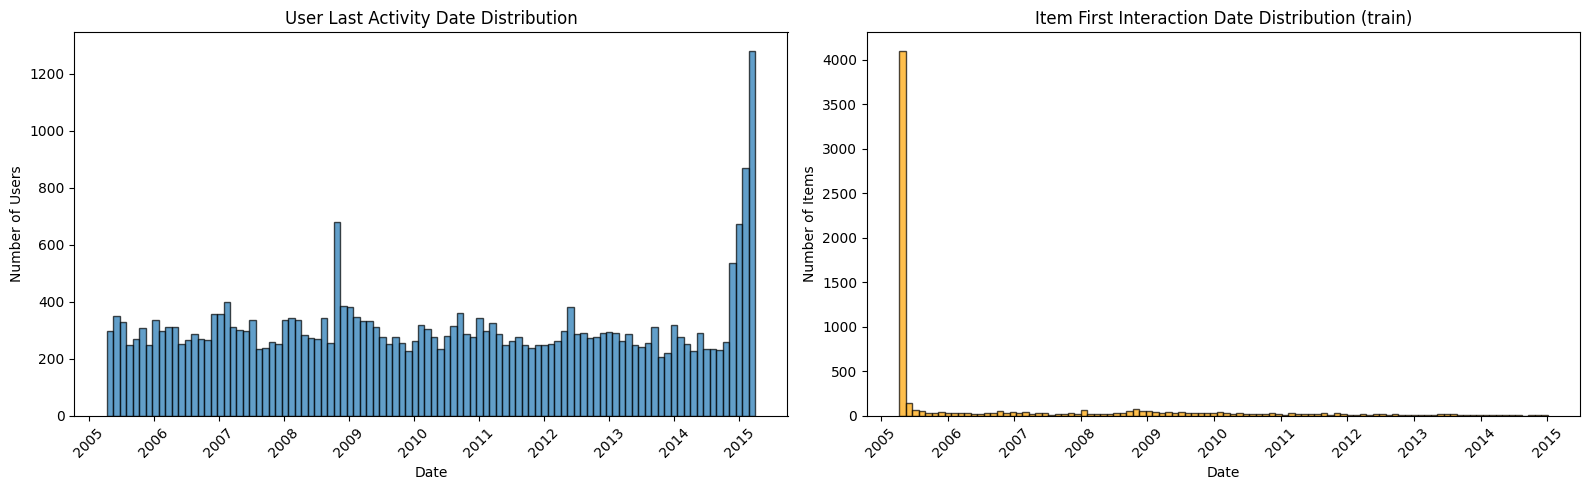

In [7]:
# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(user_last_dates, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Last Activity Date Distribution')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(item_first_dates, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Items')
axes[1].set_title('Item First Interaction Date Distribution (train)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 2. 시간 불일치 분석

In [8]:
def analyze_mismatch(submission_df, margin_hours=0):
    """
    시간 불일치 분석
    
    Parameters:
    - submission_df: 제출 파일 DataFrame
    - margin_hours: 여유 시간 (시간 단위)
    
    Returns:
    - 분석 결과 DataFrame
    """
    margin_seconds = margin_hours * 3600
    
    results = []
    for _, row in submission_df.iterrows():
        user = row['user']
        item = row['item']
        
        # 유저의 마지막 활동 시점
        user_last = user_last_time.get(user, None)
        # 아이템의 첫 상호작용 시점
        item_first = item_first_time.get(item, None)
        
        if user_last is None or item_first is None:
            # 데이터 없음 (새 아이템 등)
            mismatch = None
            gap_seconds = None
        else:
            # 불일치 판단: user_last + margin < item_first
            mismatch = (user_last + margin_seconds) < item_first
            gap_seconds = item_first - user_last if mismatch else 0
        
        results.append({
            'user': user,
            'item': item,
            'user_last_time': user_last,
            'item_first_time': item_first,
            'mismatch': mismatch,
            'gap_seconds': gap_seconds
        })
    
    return pd.DataFrame(results)

In [9]:
# === margin 값 설정 (시간 단위) ===
MARGIN_HOURS = 0  # 여유 시간

analysis_df = analyze_mismatch(submission, MARGIN_HOURS)
print(f"분석 완료 (margin = {MARGIN_HOURS}시간)")

분석 완료 (margin = 0시간)


In [10]:
# 불일치 통계
total_predictions = len(analysis_df)
valid_predictions = analysis_df['mismatch'].notna().sum()
mismatch_count = analysis_df['mismatch'].sum()
mismatch_rate = mismatch_count / valid_predictions * 100 if valid_predictions > 0 else 0

print("=" * 60)
print(f"[불일치 분석 결과] (margin = {MARGIN_HOURS}시간)")
print("=" * 60)
print(f"총 예측 수: {total_predictions:,}")
print(f"분석 가능 예측 수: {valid_predictions:,}")
print(f"불일치 예측 수: {mismatch_count:,}")
print(f"불일치 비율: {mismatch_rate:.2f}%")

[불일치 분석 결과] (margin = 0시간)
총 예측 수: 313,600
분석 가능 예측 수: 313,600
불일치 예측 수: 732
불일치 비율: 0.23%


In [11]:
# 다양한 margin 값으로 테스트
def test_multiple_margins(submission_df, margin_hours_list):
    results = []
    for margin in margin_hours_list:
        margin_seconds = margin * 3600
        
        mismatch_count = 0
        valid_count = 0
        
        for _, row in submission_df.iterrows():
            user = row['user']
            item = row['item']
            
            user_last = user_last_time.get(user, None)
            item_first = item_first_time.get(item, None)
            
            if user_last is not None and item_first is not None:
                valid_count += 1
                if (user_last + margin_seconds) < item_first:
                    mismatch_count += 1
        
        mismatch_rate = mismatch_count / valid_count * 100 if valid_count > 0 else 0
        results.append({
            'margin_hours': margin,
            'mismatch_count': mismatch_count,
            'mismatch_rate': mismatch_rate
        })
    
    return pd.DataFrame(results)

# 테스트할 margin 값들
MARGIN_LIST = [0, 1, 6, 24, 72, 720]  # 0시간 ~ 30일
margin_results = test_multiple_margins(submission, MARGIN_LIST)

print("[다양한 margin 값에 따른 불일치 비율]")
print(margin_results.to_string(index=False))

[다양한 margin 값에 따른 불일치 비율]
 margin_hours  mismatch_count  mismatch_rate
            0             732       0.233418
            1             729       0.232462
            6             716       0.228316
           24             704       0.224490
           72             680       0.216837
          720             449       0.143176


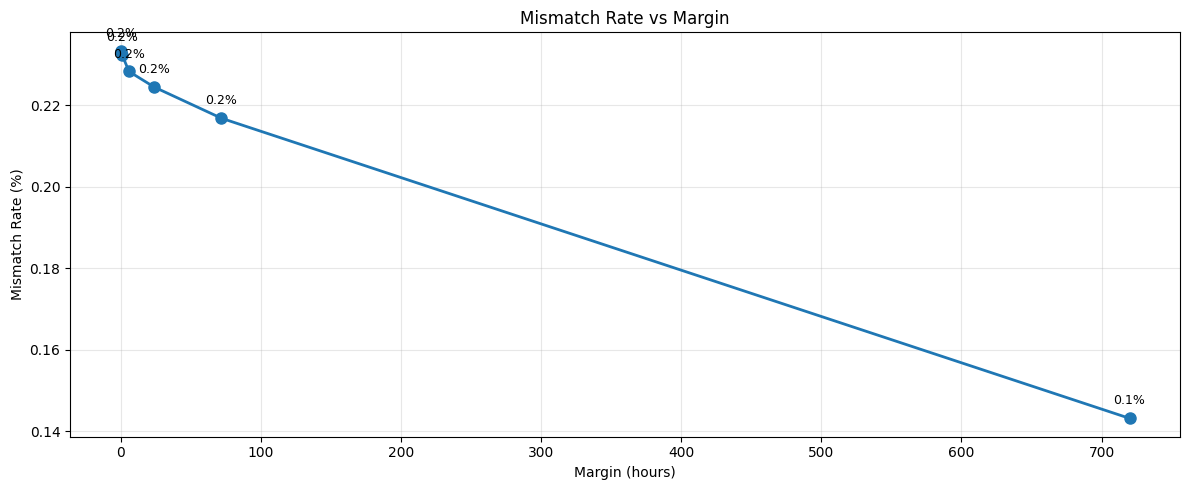

In [12]:
# 시각화
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(margin_results['margin_hours'], margin_results['mismatch_rate'], 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Margin (hours)')
ax.set_ylabel('Mismatch Rate (%)')
ax.set_title('Mismatch Rate vs Margin')
ax.grid(alpha=0.3)

# 주요 지점 표시
for _, row in margin_results.iterrows():
    ax.annotate(f"{row['mismatch_rate']:.1f}%", 
                (row['margin_hours'], row['mismatch_rate']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 3. 불일치 케이스 상세 분석

In [13]:
# 불일치 케이스만 필터링
mismatch_cases = analysis_df[analysis_df['mismatch'] == True].copy()

print(f"불일치 케이스 수: {len(mismatch_cases):,}")

불일치 케이스 수: 732


In [14]:
# 유저별 불일치 아이템 수
user_mismatch_count = mismatch_cases.groupby('user').size()

print("[유저별 불일치 아이템 수 분포]")
print(f"불일치가 있는 유저 수: {len(user_mismatch_count):,}")
print(f"\n불일치 아이템 수 분포:")
print(user_mismatch_count.value_counts().sort_index())

[유저별 불일치 아이템 수 분포]
불일치가 있는 유저 수: 590

불일치 아이템 수 분포:
1    492
2     73
3     16
4      5
5      2
7      1
9      1
Name: count, dtype: int64


[불일치 케이스의 시간 gap 분포]
평균: 68.6일
중앙값: 46.1일
최소: 0.0일
최대: 475.6일


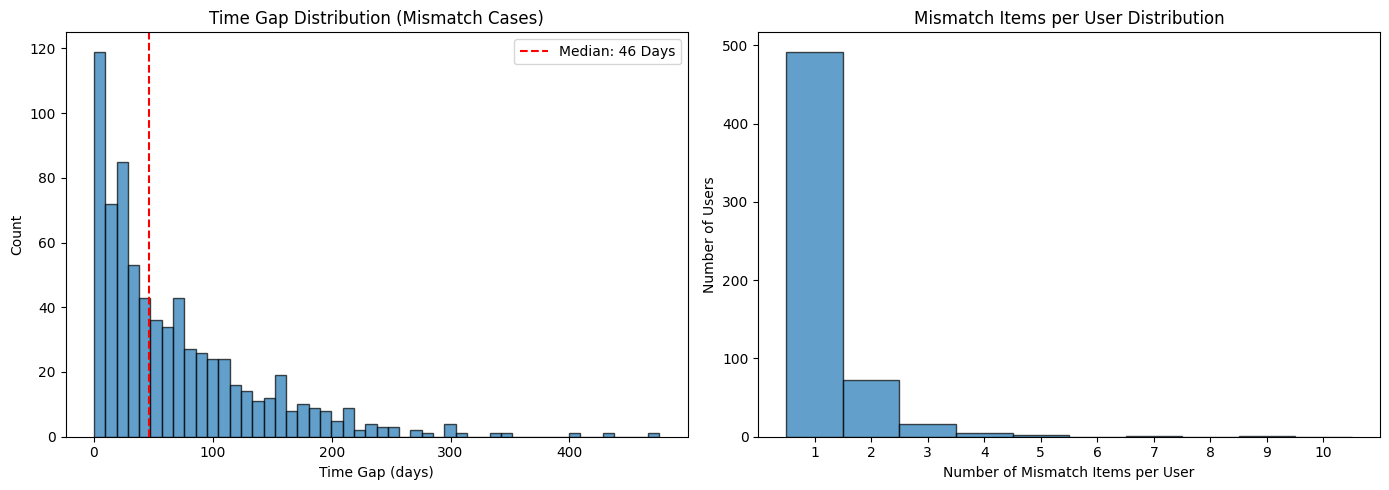

In [15]:
# 시간 gap 분포 (불일치 케이스)
if len(mismatch_cases) > 0:
    gap_hours = mismatch_cases['gap_seconds'] / 3600
    gap_days = mismatch_cases['gap_seconds'] / 86400
    
    print("[불일치 케이스의 시간 gap 분포]")
    print(f"평균: {gap_days.mean():.1f}일")
    print(f"중앙값: {gap_days.median():.1f}일")
    print(f"최소: {gap_days.min():.1f}일")
    print(f"최대: {gap_days.max():.1f}일")
    
    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(gap_days, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Time Gap (days)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Time Gap Distribution (Mismatch Cases)')
    axes[0].axvline(gap_days.median(), color='red', linestyle='--', label=f'Median: {gap_days.median():.0f} Days')
    axes[0].legend()
    
    # 유저별 불일치 수 분포
    axes[1].hist(user_mismatch_count.values, bins=range(1, 12), edgecolor='black', alpha=0.7, align='left')
    axes[1].set_xlabel('Number of Mismatch Items per User')
    axes[1].set_ylabel('Number of Users')
    axes[1].set_title('Mismatch Items per User Distribution')
    axes[1].set_xticks(range(1, 11))
    
    plt.tight_layout()
    plt.show()

In [16]:
# 불일치가 많은 유저 특성 분석
if len(user_mismatch_count) > 0:
    # 유저별 활동 기간 계산
    user_activity_span = ratings.groupby('user')['datetime'].agg(['min', 'max'])
    user_activity_span['span_days'] = (user_activity_span['max'] - user_activity_span['min']).dt.days
    
    # 불일치 유저 vs 전체 유저 비교
    mismatch_users = user_mismatch_count.index
    non_mismatch_users = set(submission['user'].unique()) - set(mismatch_users)
    
    mismatch_user_span = user_activity_span.loc[user_activity_span.index.isin(mismatch_users), 'span_days']
    non_mismatch_user_span = user_activity_span.loc[user_activity_span.index.isin(non_mismatch_users), 'span_days']
    
    print("[불일치 유저 vs 비불일치 유저 활동 기간 비교]")
    print(f"\n불일치 유저 ({len(mismatch_users)}명):")
    print(f"  활동 기간 평균: {mismatch_user_span.mean():.1f}일")
    print(f"  활동 기간 중앙값: {mismatch_user_span.median():.1f}일")
    
    print(f"\n비불일치 유저 ({len(non_mismatch_users)}명):")
    print(f"  활동 기간 평균: {non_mismatch_user_span.mean():.1f}일")
    print(f"  활동 기간 중앙값: {non_mismatch_user_span.median():.1f}일")

[불일치 유저 vs 비불일치 유저 활동 기간 비교]

불일치 유저 (590명):
  활동 기간 평균: 140.6일
  활동 기간 중앙값: 0.0일

비불일치 유저 (30770명):
  활동 기간 평균: 445.8일
  활동 기간 중앙값: 13.0일


[불일치 아이템 vs 전체 아이템 첫 상호작용 시점 비교]

불일치 아이템 (298개):
  첫 상호작용 중앙값: 2008-08-17 04:28:36

전체 아이템 (6807개):
  첫 상호작용 중앙값: 2005-04-21 12:33:21


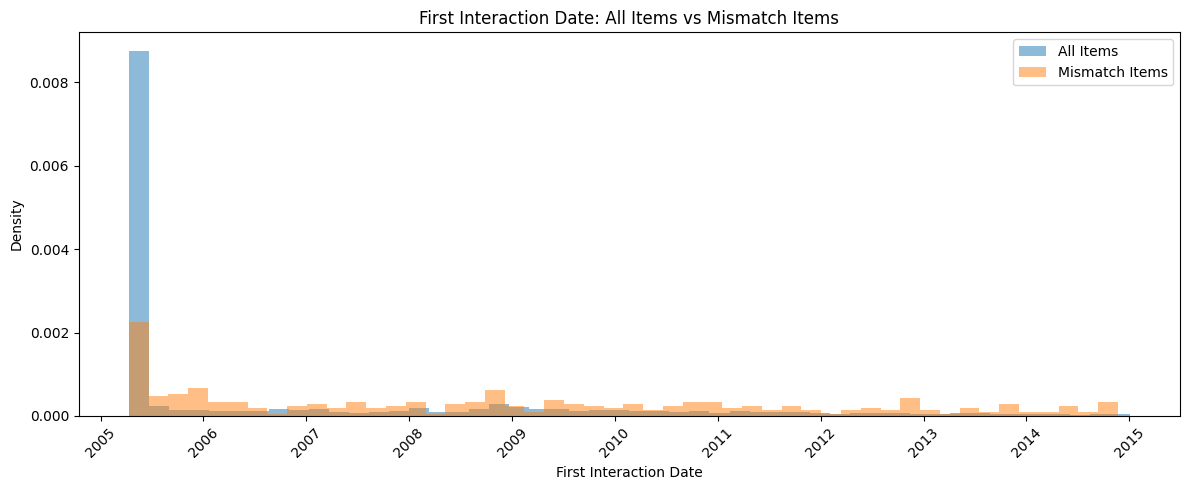

In [17]:
# 불일치 아이템 특성 분석
if len(mismatch_cases) > 0:
    mismatch_items = mismatch_cases['item'].unique()
    
    # 아이템별 첫 상호작용 시점
    mismatch_item_first = item_first_dates[item_first_dates.index.isin(mismatch_items)]
    all_item_first = item_first_dates
    
    print("[불일치 아이템 vs 전체 아이템 첫 상호작용 시점 비교]")
    print(f"\n불일치 아이템 ({len(mismatch_items)}개):")
    print(f"  첫 상호작용 중앙값: {mismatch_item_first.median()}")
    
    print(f"\n전체 아이템 ({len(all_item_first)}개):")
    print(f"  첫 상호작용 중앙값: {all_item_first.median()}")
    
    # 시각화
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(all_item_first, bins=50, alpha=0.5, label='All Items', density=True)
    ax.hist(mismatch_item_first, bins=50, alpha=0.5, label='Mismatch Items', density=True)
    ax.set_xlabel('First Interaction Date')
    ax.set_ylabel('Density')
    ax.set_title('First Interaction Date: All Items vs Mismatch Items')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

---
## 4. 요약 및 시사점

In [18]:
print("=" * 60)
print("[제출 파일 시간 불일치 분석 요약]")
print("=" * 60)

print(f"\n1. 기본 정보")
print(f"   - 총 예측 수: {total_predictions:,}")
print(f"   - 유저 수: {submission['user'].nunique():,}")
print(f"   - 유저당 예측: 10개")

print(f"\n2. 불일치 분석 (margin = {MARGIN_HOURS}시간)")
print(f"   - 불일치 예측 수: {mismatch_count:,}")
print(f"   - 불일치 비율: {mismatch_rate:.2f}%")

if len(mismatch_cases) > 0:
    print(f"\n3. 불일치 케이스 특성")
    print(f"   - 불일치가 있는 유저: {len(user_mismatch_count):,}명")
    print(f"   - 시간 gap 중앙값: {gap_days.median():.1f}일")

[제출 파일 시간 불일치 분석 요약]

1. 기본 정보
   - 총 예측 수: 313,600
   - 유저 수: 31,360
   - 유저당 예측: 10개

2. 불일치 분석 (margin = 0시간)
   - 불일치 예측 수: 732
   - 불일치 비율: 0.23%

3. 불일치 케이스 특성
   - 불일치가 있는 유저: 590명
   - 시간 gap 중앙값: 46.1일


---
## 5. 추가 탐색 (개별 케이스 확인)

In [19]:
# 불일치가 가장 많은 유저 확인
if len(user_mismatch_count) > 0:
    top_mismatch_users = user_mismatch_count.nlargest(10)
    print("[불일치가 가장 많은 유저 Top 10]")
    for user, count in top_mismatch_users.items():
        user_last = pd.to_datetime(user_last_time[user], unit='s')
        print(f"  User {user}: {count}개 불일치, 마지막 활동: {user_last.date()}")

[불일치가 가장 많은 유저 Top 10]
  User 6444: 9개 불일치, 마지막 활동: 2005-04-11
  User 21070: 7개 불일치, 마지막 활동: 2005-06-28
  User 43767: 5개 불일치, 마지막 활동: 2005-04-13
  User 83779: 5개 불일치, 마지막 활동: 2006-04-25
  User 3894: 4개 불일치, 마지막 활동: 2007-11-07
  User 68341: 4개 불일치, 마지막 활동: 2005-11-09
  User 99208: 4개 불일치, 마지막 활동: 2005-04-14
  User 114302: 4개 불일치, 마지막 활동: 2005-04-13
  User 130175: 4개 불일치, 마지막 활동: 2006-12-13
  User 11095: 3개 불일치, 마지막 활동: 2013-02-06


In [20]:
# 특정 유저의 불일치 상세 확인
def show_user_mismatch_detail(user_id):
    user_cases = analysis_df[analysis_df['user'] == user_id]
    user_last = pd.to_datetime(user_last_time.get(user_id), unit='s')
    
    print(f"[User {user_id} 상세]")
    print(f"마지막 활동: {user_last}")
    print(f"\n예측 아이템 (10개):")
    
    for _, row in user_cases.iterrows():
        item = row['item']
        item_first = pd.to_datetime(row['item_first_time'], unit='s') if row['item_first_time'] else None
        mismatch = row['mismatch']
        gap = row['gap_seconds'] / 86400 if row['gap_seconds'] else 0
        
        status = "❌ 불일치" if mismatch else "✅ 일치"
        print(f"  Item {item}: 첫 상호작용 {item_first}, {status}" + (f" (gap: {gap:.0f}일)" if mismatch else ""))

# 예시: 불일치가 많은 유저 확인
# show_user_mismatch_detail(USER_ID)

In [21]:
show_user_mismatch_detail(6444)

[User 6444 상세]
마지막 활동: 2005-04-11 13:54:15

예측 아이템 (10개):
  Item 1198: 첫 상호작용 2005-04-11 21:39:25, ❌ 불일치 (gap: 0일)
  Item 1136: 첫 상호작용 2005-04-11 19:12:48, ❌ 불일치 (gap: 0일)
  Item 104: 첫 상호작용 2005-04-11 17:55:38, ❌ 불일치 (gap: 0일)
  Item 480: 첫 상호작용 2005-04-11 15:50:34, ❌ 불일치 (gap: 0일)
  Item 6539: 첫 상호작용 2005-04-11 18:38:27, ❌ 불일치 (gap: 0일)
  Item 2918: 첫 상호작용 2005-04-11 12:42:10, ✅ 일치
  Item 2502: 첫 상호작용 2005-04-11 15:15:44, ❌ 불일치 (gap: 0일)
  Item 588: 첫 상호작용 2005-04-11 18:20:25, ❌ 불일치 (gap: 0일)
  Item 520: 첫 상호작용 2005-04-11 15:58:22, ❌ 불일치 (gap: 0일)
  Item 364: 첫 상호작용 2005-04-11 17:51:06, ❌ 불일치 (gap: 0일)
